In [12]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import accuracy_score
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [ ]:
# Cargar datos
columnas = ["age","workclass","fnlwgt","education","education_num",
            "marital_status","occupation","relationship","race","sex",
            "capital_gain","capital_loss","hours_per_week","native_country","income"]

df = pd.read_csv("adult.data", header=None, names=columnas, sep=",", skipinitialspace=True)

columns = ["age","workclass","fnlwgt","education","education_num","marital_status",
           "occupation","relationship","race","sex","capital_gain","capital_loss",
           "hours_per_week","native_country","income"]

encoders = {}
for col in df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le  # guardamos para convertir luego nuevos datos

X = df.drop("income", axis=1).values
Y = df["income"].values  # 0 = <=50K, 1 = >50K

X_train, X_val, y_train, y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
class TabularDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = {
    'train' : TabularDataset(X_train, y_train),
    'val' : TabularDataset(X_val, y_val),
}

dataloader = {
    'train': torch.utils.data.DataLoader(dataset['train'], batch_size=32, shuffle=True),
    'val': torch.utils.data.DataLoader(dataset['val'], batch_size=1000, shuffle=False)
}

In [ ]:
def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(axis=-1,keepdims=True)

In [18]:

def build_model(D_in=X_train.shape[1], H=16, D_out=2):
    return torch.nn.Sequential(
        torch.nn.Linear(D_in, H),
        torch.nn.ReLU(),
        torch.nn.Linear(H, H),
        torch.nn.ReLU(),
        torch.nn.Linear(H, D_out)
    )

In [ ]:
def fit(model, dataloader, epochs=200, log_each=10, weight_decay=1e-4, early_stopping=20):
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=weight_decay)

    l, acc = [], []
    val_l, val_acc = [], []
    best_acc, step = 0, 0

    for e in range(1, epochs+1):
        _l, _acc = [], []
        model.train()
        for x_b, y_b in dataloader['train']:
            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            _l.append(loss.item())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            y_probas = torch.argmax(softmax(y_pred), axis=1)
            _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().detach().numpy()))

        l.append(np.mean(_l))
        acc.append(np.mean(_acc))

        # --- validación ---
        model.eval()
        _l, _acc = [], []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                _l.append(loss.item())
                y_probas = torch.argmax(softmax(y_pred), axis=1)
                _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().numpy()))
        val_l.append(np.mean(_l))
        val_acc.append(np.mean(_acc))

        # guardar mejor modelo
        if val_acc[-1] > best_acc:
            best_acc = val_acc[-1]
            torch.save(model.state_dict(), 'ckpt.pt')
            step = 0
            print(f"Mejor modelo guardado con acc {best_acc:.5f} en epoch {e}")
        else:
            step += 1

        # parar por early stopping
        if early_stopping and step > early_stopping:
            print(f"Entrenamiento detenido en epoch {e} por no mejorar en {early_stopping} epochs seguidas")
            break

        if not e % log_each:
            print(f"Epoch {e}/{epochs} loss {l[-1]:.5f} acc {acc[-1]:.5f} "
                  f"val_loss {val_l[-1]:.5f} val_acc {val_acc[-1]:.5f}")

    # cargar mejor modelo
    model.load_state_dict(torch.load('ckpt.pt'))

    return {
        'epoch': list(range(1, len(l)+1)),
        'loss': l, 'acc': acc,
        'val_loss': val_l, 'val_acc': val_acc
    }

In [28]:
# --- Entrenamiento ---
model = build_model()
hist = fit(model, dataloader, early_stopping=20)


Mejor modelo guardado con acc 0.76243 en epoch 1
Mejor modelo guardado con acc 0.77271 en epoch 2
Epoch 10/200 loss 0.55058 acc 0.76037 val_loss 0.55045 val_acc 0.75905
Mejor modelo guardado con acc 0.78530 en epoch 16
Mejor modelo guardado con acc 0.79604 en epoch 17
Mejor modelo guardado con acc 0.79711 en epoch 18
Mejor modelo guardado con acc 0.79819 en epoch 19
Mejor modelo guardado con acc 0.79988 en epoch 20
Epoch 20/200 loss 0.49732 acc 0.79127 val_loss 0.48135 val_acc 0.79988
Epoch 30/200 loss 0.54736 acc 0.76332 val_loss 0.54303 val_acc 0.76550
Mejor modelo guardado con acc 0.80141 en epoch 36
Mejor modelo guardado con acc 0.80279 en epoch 37
Mejor modelo guardado con acc 0.80402 en epoch 38
Epoch 40/200 loss 0.49614 acc 0.79714 val_loss 0.48686 val_acc 0.80249
Mejor modelo guardado con acc 0.80448 en epoch 43
Epoch 50/200 loss 0.52018 acc 0.78605 val_loss 0.50055 val_acc 0.79573
Epoch 60/200 loss 0.54101 acc 0.76497 val_loss 0.53937 val_acc 0.76811
Entrenamiento detenido en 

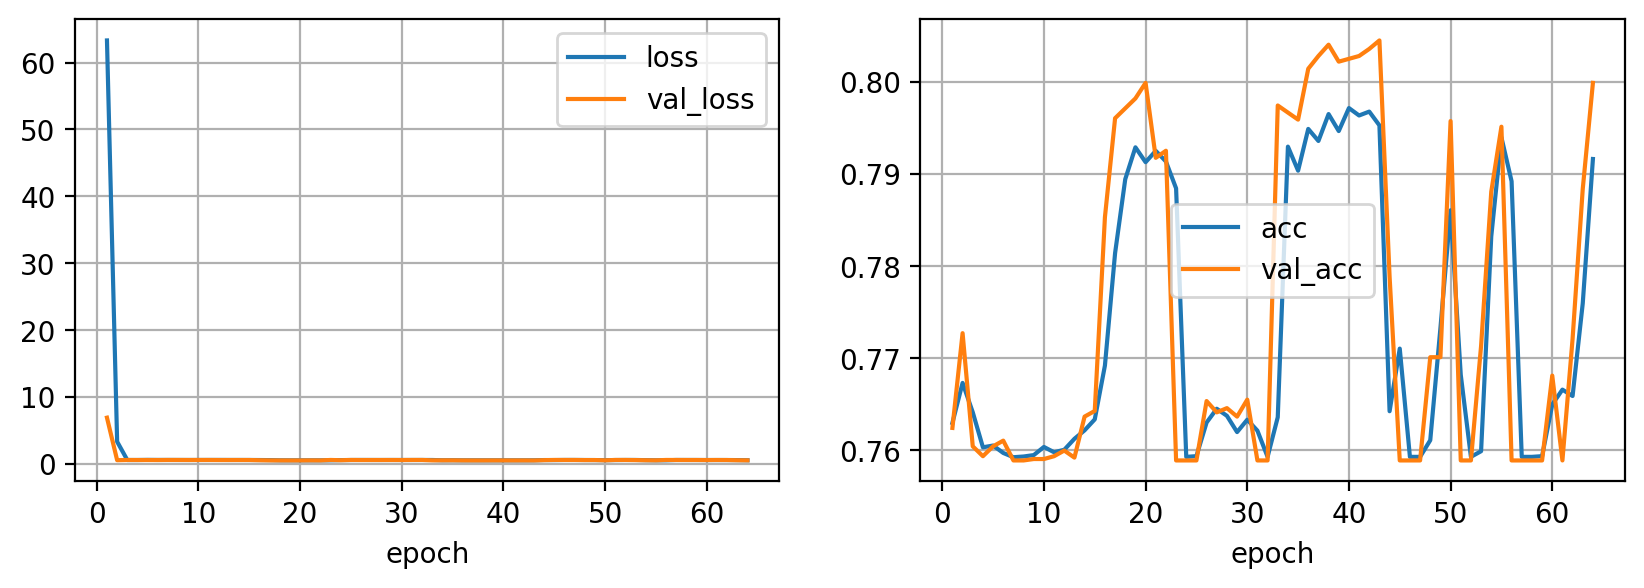

In [29]:
# --- GRAFICAR ---
fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
pd.DataFrame(hist).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(122)
pd.DataFrame(hist).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
plt.show()

In [38]:
# 12) Evaluación en test
model.eval()
with torch.no_grad():
    y_pred_test = model(X_test).numpy()
    mse_test = np.mean((y_pred_test - Y_test.numpy())**2)
    print(f"Error cuadrático medio en Test: {mse_test:.4f}")

Error cuadrático medio en Test: 123.2799


In [41]:
# 13) Ejemplo de pronóstico
ejemplo = X_test[0].unsqueeze(0)
edad_pred = model(ejemplo).item()
print("Edad real:", Y_test[0].item(), "Edad predicha:", edad_pred)

Edad real: 32.0 Edad predicha: 24.723556518554688
